<a href="https://colab.research.google.com/github/oliveira-silva-lucas/titanic/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projeto de estudo com a finalidade de aplicar os conhecimentos adquiridos por meio da leitura de livros.

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def carregar_arquivos():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://homl.info/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

    titanic_treino = pd.read_csv(Path("datasets/titanic/train.csv"))
    titanic_teste = pd.read_csv(Path("datasets/titanic/test.csv"))
    return titanic_treino, titanic_teste

titanic_treino, titanic_teste = carregar_arquivos()

In [ ]:
titanic_treino.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Já é possível observar que a informação de sexo terá que ser tratada, também podemos tratar a cabine para extrair a letra inicial

In [ ]:
titanic_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic_treino['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


Interessante observar que tem mais pessoas de primeira classe do que de segunda

In [ ]:
titanic_treino["Sex"].value_counts()

,count
Sex,
male,577
female,314


Há bem mais homens que mulheres

In [ ]:
#Irmãos e esposas
titanic_treino['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [ ]:
#Pais e Filhos
titanic_treino['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [ ]:
#Local do Embarque
titanic_treino["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


##Pré-Processamento ##

In [73]:
titanic_exploracao = titanic_treino.copy()

In [74]:
titanic_exploracao["Mulher"] = titanic_exploracao["Sex"].map({"female":1 , "male":0})

Extração da Inicial da cabine

In [ ]:
#Classe da Cabine
titanic_exploracao["Cabin"].str[0].value_counts()

,count
Cabin,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [75]:
titanic_exploracao["Cabin"] = titanic_exploracao["Cabin"].str[0]

Para preencher os valores nulos de idade podemos usar a média.

In [ ]:
titanic_exploracao['Age'].describe()

,Age
count,714.000000
mean,29.699113
std,14.526507
min,0.416700
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
#Primeira observação de correlação com a informação de sobrevivente
titanic_exploracao.corr(numeric_only=True)["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Mulher,0.543351
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


Vimos que há mais homens que mulheres, com isso já seria uma melhor escolha preencher com a `média por sexo`. Observando a correlação das colunas com a sobrevivência, também há uma forte correlação com `Pclass`, vamos observar como se comporta os valores médios com essa nova divisão.

In [ ]:
titanic_exploracao.groupby(["Sex","Pclass"])["Age"].describe()

count       mean        std     min     25%   50%    75%   max
Sex    Pclass                                                                
female 1        85.0  34.611765  13.612052  2.0000  23.000  35.0  44.00  63.0
       2        74.0  28.722973  12.872702  2.0000  22.250  28.0  36.00  57.0
       3       102.0  21.750000  12.729964  0.7500  14.125  21.5  29.75  63.0
male   1       101.0  41.281353  15.139658  0.9167  30.000  40.0  51.00  80.0
       2        99.0  30.740740  14.793826  0.6667  23.000  30.0  36.75  70.0
       3       253.0  26.507576  12.159542  0.4167  20.000  25.0  33.00  74.0

A representatividade se encaixa melhor, quanto maior a classe mais novos são os passageiros e de forma geral os homens são mais velhos que as mulheres

In [76]:
titanic_exploracao["Age"] = titanic_exploracao.groupby(["Sex","Pclass"])["Age"].transform(lambda x: x.fillna(x.mean()))

Transformar colunas categoricas de texto em colunas individuais binarias representando a categoria.

In [77]:
from sklearn.preprocessing import OneHotEncoder

titanic_exploracao_cat = titanic_exploracao[["Embarked", "Cabin"]]
cat_encoder = OneHotEncoder(sparse_output=False)
titanic_exploracao_cat = cat_encoder.fit_transform(titanic_exploracao_cat)
titanic_exploracao_cat = pd.DataFrame(titanic_exploracao_cat, columns=cat_encoder.get_feature_names_out(), index=titanic_exploracao.index)
titanic_exploracao_cat.head(2)

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Cabin_nan
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
titanic_exploracao = pd.concat([titanic_exploracao, titanic_exploracao_cat], axis=1)

###Desvendando o Ticket e o preço do ingresso ###

Observando os valores contidos em `Ticket` vemos repetições. Podemos concluir intuitivamente que seus valores provavelmente são multiplos pela quantidade que se repetem.

In [ ]:
titanic_exploracao["Ticket"].value_counts().head()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6


In [ ]:
titanic_exploracao.loc[titanic_exploracao["Ticket"] == "347082", ["Ticket", "Name", "Pclass", "Embarked", "Fare"]]

,Ticket,Name,Pclass,Embarked,Fare
13,347082,"Andersson, Mr. Anders Johan",3,S,31.275
119,347082,"Andersson, Miss. Ellis Anna Maria",3,S,31.275
541,347082,"Andersson, Miss. Ingeborg Constanzia",3,S,31.275
542,347082,"Andersson, Miss. Sigrid Elisabeth",3,S,31.275
610,347082,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",3,S,31.275
813,347082,"Andersson, Miss. Ebba Iris Alfrida",3,S,31.275
850,347082,"Andersson, Master. Sigvard Harald Elias",3,S,31.275


Agrupando por classe e local de embarque, vemos que o desvio padrão está elevado, em alguns casos quase o valor do ticket.

In [ ]:
titanic_exploracao.groupby(["Pclass","Embarked"])["Fare"].describe()

count        mean        std      min      25%      50%  \
Pclass Embarked                                                            
1      C          85.0  104.718529  99.093935  26.5500  49.5000  78.2667   
       Q           2.0   90.000000   0.000000  90.0000  90.0000  90.0000   
       S         127.0   70.364862  58.811278   0.0000  29.2500  52.0000   
2      C          17.0   25.358335  11.345067  12.0000  13.8625  24.0000   
       Q           3.0   12.350000   0.000000  12.3500  12.3500  12.3500   
       S         164.0   20.327439  13.630741   0.0000  13.0000  13.5000   
3      C          66.0   11.214083   4.871528   4.0125   7.2292   7.8958   
       Q          72.0   11.183393   6.721677   6.7500   7.7500   7.7500   
       S         353.0   14.644083  13.276609   0.0000   7.8542   8.0500   

                        75%       max  
Pclass Embarked                        
1      C         110.883300  512.3292  
       Q          90.000000   90.0000  
       S          83.475000  263.0000  
2      C          37.004200   41.5792  
       Q          12.350000   12.3500  
       S          26.000000   73.5000  
3      C          14.458300   22.3583  
       Q          10.218725   29.1250  
       S          16.100000   69.5500

Calculando `Fare` dividido pela quantidade de `Ticket` temos um resultado mais adequado.

In [ ]:
titanic_exploracao.loc[titanic_exploracao.groupby("Ticket")["Fare"].transform("count")>1, ["Ticket", "Fare", "Pclass", "Embarked"]].assign(
    quantidade_ticket = titanic_exploracao.groupby("Ticket")["Ticket"].transform("count"),
    preco_por_pessoa = titanic_exploracao["Fare"]/titanic_exploracao.groupby("Ticket")["Ticket"].transform("count")
    ).sort_values(["Pclass", "Embarked"], ascending=False).head(15)

,Ticket,Fare,Pclass,Embarked,quantidade_ticket,preco_por_pessoa
7,349909,21.0750,3,S,4,5.268750
8,347742,11.1333,3,S,3,3.711100
10,PP 9549,16.7000,3,S,2,8.350000
13,347082,31.2750,3,S,7,4.467857
24,349909,21.0750,3,S,4,5.268750
25,347077,31.3875,3,S,4,7.846875
38,345764,18.0000,3,S,2,9.000000
49,349237,17.8000,3,S,2,8.900000
50,3101295,39.6875,3,S,6,6.614583
59,CA 2144,46.9000,3,S,6,7.816667


Ao criar uma coluna com o cálculo hipotético do valor do ticket por pessoa, obtemos uma representação mais adequada. O desvio padrão em níveis aceitáveis. Os preços variam entre as classes, porém na primeira classe o desvio padrão ainda é elevado. No entanto, isso é compreensível, pois em um navio a primeira classe costuma oferecer diferentes níveis de acomodação, o que naturalmente amplia a faixa de preços.

In [79]:
titanic_exploracao["Preco_por_Pessoa"] = titanic_exploracao["Fare"] / titanic_exploracao.groupby("Ticket")["Ticket"].transform("count")
titanic_exploracao.groupby(["Pclass","Embarked"])["Preco_por_Pessoa"].describe()

count       mean        std      min       25%        50%  \
Pclass Embarked                                                              
1      C          85.0  54.016585  37.093842  15.5000  29.70000  41.085400   
       Q           2.0  45.000000   0.000000  45.0000  45.00000  45.000000   
       S         127.0  36.748546  23.039853   0.0000  26.55000  30.000000   
2      C          17.0  15.109312   3.755211  12.0000  13.79170  13.859733   
       Q           3.0  12.350000   0.000000  12.3500  12.35000  12.350000   
       S         164.0  13.155183   5.835646   0.0000  10.50000  13.000000   
3      C          66.0   7.968377   2.687219   4.0125   7.22500   7.229200   
       Q          72.0   7.925754   1.551887   5.8250   7.74065   7.750000   
       S         353.0   8.140477   2.479431   0.0000   7.55000   7.895800   

                       75%       max  
Pclass Embarked                       
1      C         59.400000  211.5000  
       Q         45.000000   45.0000  
       S         42.068750  221.7792  
2      C         15.045800   27.7208  
       Q         12.350000   12.3500  
       S         13.125000   32.5000  
3      C          7.889563   21.6792  
       Q          7.750000   15.5000  
       S          8.112500   22.5250

###Engenharia de Atributos ###

Criar novas colunas no dataset do Titanic para refletir hipóteses ligadas à sobrevivência. Homens muitas vezes cederam espaço para mulheres e crianças, então faz sentido relacionar sexo e idade. Também considerei classe e preço pago, já que passageiros de classes mais altas tinham mais chances de acesso ao resgate. Além disso, estar acompanhado pode ter influenciado decisões e aumentado a chance de ajuda. Essas variáveis combinadas deixam o dataset mais rico e ajudam os modelos a capturar padrões históricos de forma mais fiel.

In [81]:
titanic_exploracao_II = titanic_exploracao.copy()
titanic_exploracao_II["Pessoas_por_Familia"] = (titanic_exploracao_II["SibSp"] + titanic_exploracao_II["Parch"] + 1)
titanic_exploracao_II["Acompanhado"] = titanic_exploracao_II["Pessoas_por_Familia"] > 1
titanic_exploracao_II["Preco_por_Classe"] = titanic_exploracao_II["Preco_por_Pessoa"] / titanic_exploracao_II["Pclass"]
titanic_exploracao_II["Preco_por_Classe_por_Sexo"] = titanic_exploracao_II["Preco_por_Classe"]/titanic_exploracao_II["Sex"].map({"female":1 , "male":2})
titanic_exploracao_II["Idade_x_Classe"] = titanic_exploracao_II["Age"] * titanic_exploracao_II["Pclass"]
#homem sendo 2 penaliza a idade, mulher como é um fator positivo para sobreviver ficou como 1
titanic_exploracao_II["Idade_x_Sexo"] = titanic_exploracao_II["Age"] * titanic_exploracao_II["Sex"].map({"female":1 , "male":2})
titanic_exploracao_II["Idade_x_Sexo_x_Classe"] = titanic_exploracao_II["Pclass"] * titanic_exploracao_II["Idade_x_Sexo"]
titanic_exploracao_II["Idade_x_Sexo_x_Classe_x_Acompanhado"] = titanic_exploracao_II["Idade_x_Sexo_x_Classe"] * (titanic_exploracao_II["Acompanhado"] +1)

As colunas criadas possuem correlação significativa com sobrevivência.

Correlação não significa causalidade, mas com essas informações podemos confabular que sexo, idade, classe e estar acompanhado podem ter grande impacto na sobrevivência.

In [ ]:
titanic_exploracao_II.corr(numeric_only=True)["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Mulher,0.543351
Preco_por_Classe_por_Sexo,0.361272
Preco_por_Classe,0.260133
Fare,0.257307
Preco_por_Pessoa,0.254824
Acompanhado,0.203367
Cabin_B,0.175095
Embarked_C,0.168240
Cabin_D,0.150716


###Normalização ###

Para modelos lineares normalizar as ditribuições de alguns atributos podem melhorar o resultado.
Para avaliar se a transformação irá melhorar a performance do modelo, será criado uma cópia dos dados.

array([[<Axes: title={'center': 'Preco_por_Pessoa'}>,
        <Axes: title={'center': 'Preco_por_Classe'}>,
        <Axes: title={'center': 'Preco_por_Classe_por_Sexo'}>],
       [<Axes: title={'center': 'Idade_x_Classe'}>,
        <Axes: title={'center': 'Idade_x_Sexo'}>,
        <Axes: title={'center': 'Idade_x_Sexo_x_Classe'}>],
       [<Axes: title={'center': 'Idade_x_Sexo_x_Classe_x_Acompanhado'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

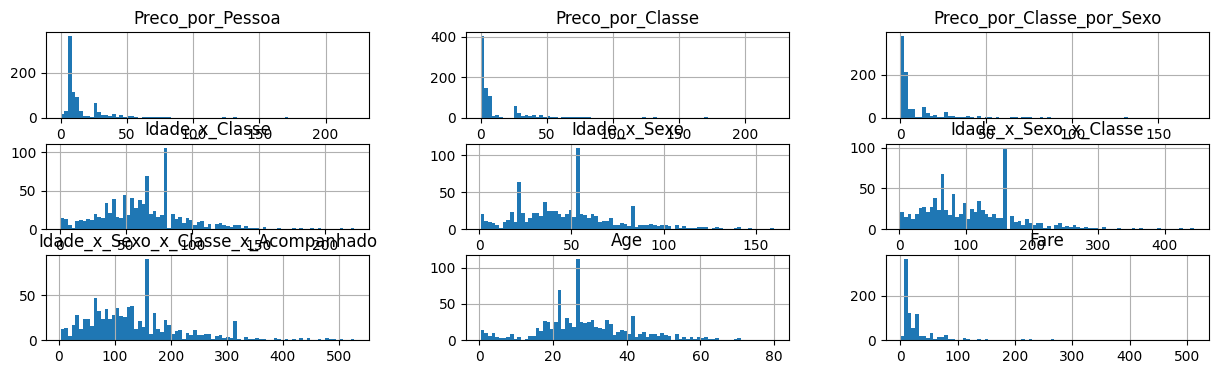

In [52]:
campos_normalizar = ["Preco_por_Pessoa",
"Preco_por_Classe",
"Preco_por_Classe_por_Sexo",
"Idade_x_Classe",
"Idade_x_Sexo",
"Idade_x_Sexo_x_Classe",
"Idade_x_Sexo_x_Classe_x_Acompanhado",
"Age",
"Fare"]
titanic_exploracao_II[campos_normalizar].hist(figsize=(15,4), bins=80)

In [67]:
from sklearn.preprocessing import PowerTransformer

titanic_exploracao_II_norm = titanic_exploracao_II.copy()

for coluna in campos_normalizar:
  pt = PowerTransformer(method='yeo-johnson')
  titanic_exploracao_II_norm[coluna] = pt.fit_transform(titanic_exploracao_II_norm[coluna].values.reshape(-1, 1)).flatten()


titanic_exploracao_norm = titanic_exploracao.copy()
titanic_exploracao_norm['Age'] = titanic_exploracao_II_norm['Age']
titanic_exploracao_norm['Fare'] = titanic_exploracao_II_norm['Fare']
titanic_exploracao_norm['Preco_por_Pessoa'] = titanic_exploracao_II_norm['Preco_por_Pessoa']

O método utilizado foi o yeo-johnson. As correlações pós transformação aumentaram.

In [ ]:
titanic_exploracao_II_norm.corr(numeric_only=True)["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Mulher,0.543351
Preco_por_Classe_por_Sexo,0.460709
Preco_por_Classe,0.345338
Fare,0.326914
Preco_por_Pessoa,0.321474
Acompanhado,0.203367
Cabin_B,0.175095
Embarked_C,0.168240
Cabin_D,0.150716


##Modelos de ML ##

Teste de aprendizagem linear e em árvore.

Serão 4 conjuntos a serem treinados:
- titanic_exploracao_std = Conjunto base.
- titanic_exploracao_norm_std =  Cojunto base com normalização.
- titanic_exploracao_II_std = Conjunto com engenharia de atributos.
- titanic_exploracao_II_norm_std = Conjunto com engenharia de atributos e normalização.

O melhor modelo e conjunto terão um pipeline para transformar o conjunto de teste.

In [82]:
from sklearn.preprocessing import StandardScaler

y_treino = titanic_exploracao_II["Survived"]
pradronizador = StandardScaler()
titanic_exploracao_std = pradronizador.fit_transform(titanic_exploracao.select_dtypes(include="number").copy().drop(columns=["Survived"]))
titanic_exploracao_norm_std = pradronizador.fit_transform(titanic_exploracao_norm.select_dtypes(include="number").copy().drop(columns=["Survived"]))
titanic_exploracao_II_std = pradronizador.fit_transform(titanic_exploracao_II.select_dtypes(include="number").copy().drop(columns=["Survived"]))
titanic_exploracao_II_norm_std = pradronizador.fit_transform(titanic_exploracao_II_norm.select_dtypes(include="number").copy().drop(columns=["Survived"]))

###Logistic Regression ###


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

log_reg = LogisticRegression(random_state=42)

t_e_I_score = cross_val_score(log_reg, titanic_exploracao_std, y_treino, cv=10, scoring="accuracy")
t_e_I_norm_score = cross_val_score(log_reg, titanic_exploracao_norm_std, y_treino, cv=10, scoring="accuracy")
t_e_II_score = cross_val_score(log_reg, titanic_exploracao_II_std, y_treino, cv=10, scoring="accuracy")
t_e_II_norm_score = cross_val_score(log_reg, titanic_exploracao_II_norm_std, y_treino, cv=10, scoring="accuracy")

print(t_e_I_score.mean())
print(t_e_I_norm_score.mean())
print(t_e_II_score.mean())
print(t_e_II_norm_score.mean())

0.8013732833957553
0.804769038701623
0.8170911360799
0.818214731585518


Com a criação de novas variáveis através da engenharia de dados, o desempenho dos modelos no Titanic melhorou em relação ao dataset original. Essa abordagem capturou melhor as interações entre idade, sexo, classe e contexto social, resultando em ganhos consistentes. Além disso, quando aplicamos normalização sobre o dataset enriquecido, o modelo apresentou performance ainda superior. No geral, os modelos com engenharia de dados foram cerca de 2% mais eficientes, mostrando que tanto a construção de novas features quanto a normalização são passos importantes para aumentar a qualidade das previsões.

A próxima etapa será realizar um grid search para otimizar os hiperparâmetros.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_lg = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "penalty": ["l2"],
        "solver": ["liblinear", "saga"],
        "C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": [0.01, 0.1, 1, 10, 100],
        "l1_ratio": [0.1, 0.5, 0.7, 0.9]
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=42),
    param_grid=param_grid_lg,
    cv=10,
    n_jobs=-1,
    verbose=2,
    scoring="accuracy"
)

grid_search.fit(titanic_exploracao_II_std, y_treino)
mehores_parametros = grid_search.best_params_
melhor_score = grid_search.best_score_

grid_search.fit(titanic_exploracao_II_norm_std, y_treino)


Fitting 10 folds for each of 40 candidates, totalling 400 fits
Fitting 10 folds for each of 40 candidates, totalling 400 fits


GridSearchCV(cv=10,
             estimator=LogisticRegression(max_iter=10000, random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'l1_ratio': [0.1, 0.5, 0.7, 0.9],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='accuracy', verbose=2)

In [ ]:
print("Melhores parâmetros:", mehores_parametros)
print("Melhor score:", melhor_score)
print("*********************************************")
print("Melhores parâmetros para modelo normalizado:", grid_search.best_params_)
print("Melhor score para modelo normalizado:", grid_search.best_score_)

Melhores parâmetros: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Melhor score: 0.8271785268414481
*********************************************
Melhores parâmetros para modelo normalizado: {'C': 10, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Melhor score para modelo normalizado: 0.8249438202247192


Com os dois melhores datasets, o enriquecido com engenharia de dados e sua versão normalizada. O resultado mostrou que o dataset normalizado alcançou uma acurácia de **0.8249**, enquanto o dataset apenas com engenharia de dados obteve **0.8271**. Apesar da diferença ser pequena, fica claro que a engenharia de dados trouxe ganhos consistentes em relação ao dataset original, e que a normalização, embora não tenha superado o desempenho, ainda contribuiu para tornar o modelo mais estável e robusto.

In [ ]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

nomes_colunas = titanic_exploracao_II.select_dtypes(include="number").drop(columns=["Survived"]).columns

melhor_modelo = LogisticRegression(C=100, penalty='l1', solver='liblinear', random_state=42)
melhor_modelo.fit(titanic_exploracao_II_std, y_treino)

importancia_colunas = pd.DataFrame({
    "Feature": nomes_colunas,
    "Coeficiente": melhor_modelo.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

print("\nImportância das colunas (coeficientes):")
importancia_colunas



Importância das colunas (coeficientes):


,Feature,Coeficiente
2,Age,3.248168
26,Idade_x_Sexo_x_Classe,2.551750
20,Preco_por_Pessoa,0.816062
6,Mulher,0.672199
15,Cabin_E,0.302440
5,Fare,0.206878
14,Cabin_D,0.180618
10,Embarked_nan,0.128728
12,Cabin_B,0.115611
11,Cabin_A,0.107562


A análise dos coeficientes evidencia quais variáveis tiveram maior impacto na previsão de sobrevivência. Entre os fatores mais relevantes, destacam‑se ***Age (3.24)*** e ***Idade_x_Sexo_x_Classe (2.55)***, indicando que idade combinada com sexo e classe social foi decisiva. Também aparecem com peso positivo variáveis como ***Preço por Pessoa (0.82)*** e ***Mulher (0.67)***, reforçando a hipótese histórica de que mulheres e passageiros com maior poder aquisitivo tiveram mais chances de sobreviver.

Por outro lado, algumas variáveis apresentaram coeficientes negativos, como ***Idade_x_Sexo (-3.94)***, ***Idade_x_Classe (-2.81)*** e ***Preço por Classe (-1.04)***, sugerindo que, em determinadas combinações, idade avançada, classe mais baixa e custo relativo do bilhete reduziram a probabilidade de sobrevivência. Também se destacam negativamente fatores como ***Pclass (-0.40)*** e ***SibSp (-0.26)***, mostrando que estar em classes inferiores ou acompanhado de muitos familiares poderia diminuir as chances.

Em resumo, o modelo conseguiu capturar padrões historicamente plausíveis: mulheres, jovens e passageiros de maior poder aquisitivo tiveram vantagem, enquanto idade elevada e classe social mais baixa pesaram contra. A acurácia obtida confirma que a engenharia de dados aplicada gerou variáveis úteis e que o modelo conseguiu traduzir essas relações em previsões consistentes.

###Random Forest Classifier ###

In [83]:
from numpy import random
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)

t_e_I_score = cross_val_score(random_forest, titanic_exploracao_std, y_treino, cv=10, scoring="accuracy")
t_e_I_norm_score = cross_val_score(random_forest, titanic_exploracao_norm_std, y_treino, cv=10, scoring="accuracy")
t_e_II_score = cross_val_score(random_forest, titanic_exploracao_II_std, y_treino, cv=10, scoring="accuracy")
t_e_II_norm_score = cross_val_score(random_forest, titanic_exploracao_II_norm_std, y_treino, cv=10, scoring="accuracy")

print(t_e_I_score.mean())
print(t_e_I_norm_score.mean())
print(t_e_II_score.mean())
print(t_e_II_norm_score.mean())

0.8159550561797753
0.8170786516853932
0.821585518102372
0.819338327091136


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Grid de hiperparâmetros
param_grid = {
    "n_estimators": [300, 600, 1000, 1500, 2000],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2],
}

# Configuração do GridSearch
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=10,
    verbose=2,
    scoring="accuracy",
    n_jobs=-1
)


grid_search.fit(titanic_exploracao_II_std, y_treino)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor score:", grid_search.best_score_)

Fitting 10 folds for each of 150 candidates, totalling 1500 fits
Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 600}
Melhor score: 0.8373033707865168


In [ ]:
resultados = pd.DataFrame(grid_search.cv_results_)
top_25_modelos = resultados.sort_values(by="mean_test_score", ascending=False).head(25)

colunas_param = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                   'param_min_samples_leaf','mean_test_score', 'std_test_score']

display(top_25_modelos[colunas_param])

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
47,1000,10,2,2,0.837303,0.044822
36,600,10,5,1,0.837303,0.047556
45,300,10,2,2,0.837291,0.045722
106,600,30,2,2,0.836192,0.045583
16,600,None,2,2,0.836192,0.045583
136,600,40,2,2,0.836192,0.045583
29,2000,None,10,2,0.836180,0.042500
48,1500,10,2,2,0.836180,0.043672
107,1000,30,2,2,0.836180,0.043382
51,600,10,5,2,0.836180,0.045927


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

nomes_colunas = titanic_exploracao_II.select_dtypes(include="number").drop(columns=["Survived"]).columns

lista_importancia_colunas = []

# 5 Melhores modelos
for i in range(5):
    parametros_modelo = top_25_modelos.iloc[i]

    params = {
        'n_estimators': parametros_modelo['param_n_estimators'],
        'max_depth': parametros_modelo['param_max_depth'],
        'min_samples_split': parametros_modelo['param_min_samples_split'],
        'min_samples_leaf': parametros_modelo['param_min_samples_leaf'],
    }

    modelo = RandomForestClassifier(random_state=42, **params)
    modelo.fit(titanic_exploracao_II_std, y_treino)

    lista_importancia_colunas.append({
        'Modelo_Posicao': i + 1,
        'Modelo_Pontuacao': parametros_modelo['mean_test_score'],
        'Importancia_Colunas': modelo.feature_importances_
    })

importancias_df = pd.DataFrame(index=nomes_colunas)

for item in lista_importancia_colunas:
    importancias_df[f'Modelo_{item["Modelo_Posicao"]} (Score CV: {item["Modelo_Pontuacao"]:.4f})'] = item['Importancia_Colunas']


display(importancias_df.mean(axis=1).sort_values(ascending=False).to_frame(name='Importancia_Media'))
print("Comparativo dos melhores modelos")
display(importancias_df.sort_values(by=importancias_df.columns[0], ascending=False))

,Importancia_Media
Idade_x_Sexo_x_Classe,0.148822
Mulher,0.131286
Preco_por_Classe_por_Sexo,0.104521
Idade_x_Sexo_x_Classe_x_Acompanhado,0.091168
Idade_x_Sexo,0.079879
Preco_por_Classe,0.063992
Fare,0.058265
Preco_por_Pessoa,0.057503
Idade_x_Classe,0.053222
PassengerId,0.052612


Comparativo dos melhores modelos


,Modelo_1 (Score CV: 0.8373),Modelo_2 (Score CV: 0.8373),Modelo_3 (Score CV: 0.8373),Modelo_4 (Score CV: 0.8362),Modelo_5 (Score CV: 0.8362)
Idade_x_Sexo_x_Classe,0.149067,0.148123,0.149146,0.148887,0.148887
Mulher,0.132547,0.135530,0.129551,0.129402,0.129402
Preco_por_Classe_por_Sexo,0.107998,0.104240,0.106983,0.101691,0.101691
Idade_x_Sexo_x_Classe_x_Acompanhado,0.089048,0.091621,0.095452,0.089858,0.089858
Idade_x_Sexo,0.081532,0.079056,0.080000,0.079405,0.079405
Preco_por_Classe,0.064496,0.063265,0.063308,0.064445,0.064445
Fare,0.057721,0.054028,0.061047,0.059265,0.059265
Preco_por_Pessoa,0.055674,0.057615,0.055787,0.059220,0.059220
Idade_x_Classe,0.053979,0.051451,0.052652,0.054013,0.054013
PassengerId,0.049395,0.049888,0.049480,0.057149,0.057149


Após a execução do Grid Search, foram identificados cinco modelos com desempenho muito próximo, apresentando scores médios de validação cruzada entre ***0.8362*** e ***0.8373***. Isso mostra que o algoritmo conseguiu encontrar configurações de hiperparâmetros estáveis, sem grandes variações de performance entre os melhores candidatos.

A análise das importâncias das features revela quais atributos mais contribuíram para a capacidade preditiva do modelo:

- ***Idade_x_Sexo_x_Classe (≈ 0.149)*** → combinação de idade, sexo e classe social foi o fator mais relevante.

- ***Mulher (≈ 0.132)*** → o gênero feminino isoladamente teve grande peso, refletindo a prioridade dada às mulheres no resgate.

- ***Preço_por_Classe_por_Sexo (≈ 0.105)*** → variável que relaciona tarifa, classe e sexo também se destacou.

- ***Idade_x_Sexo_x_Classe_x_Acompanhado*** (≈ 0.091) → acrescentar a informação de estar acompanhado aumentou a relevância.

- ***Idade_x_Sexo (≈ 0.080)*** → reforça que idade e sexo são determinantes.

- Outras variáveis como Fare, Preço_por_Pessoa, Idade_x_Classe e até mesmo PassengerId tiveram relevância moderada.

- Variáveis originais como Pclass, SibSp, Parch e Embarked tiveram menor impacto.

- As variáveis de cabine (Cabin_X) e embarque (Embarked_X) apresentaram importâncias muito baixas, praticamente irrelevantes.

O modelo confirma que ***sexo***, ***idade*** e ***classe social*** foram os fatores mais determinantes para a sobrevivência no Titanic.

As variáveis derivadas e combinadas (interações) tiveram muito mais peso que as variáveis originais isoladas, mostrando que a engenharia de atributos foi fundamental para melhorar o desempenho.

A proximidade dos scores entre os melhores modelos indica que o RandomForest conseguiu capturar padrões robustos e estáveis, sem depender excessivamente de um único hiperparâmetro.

#Predição Final #

Criação do pipeline para o modelo final, predição e resultado de sobrevivência.

O `StandardScaler` foi removido do pipeline, pois em modelos baseados em árvores não há necessidade de padronização. Ele estava presente anteriormente porque dentre os modelos testados havia modelo linear, e nesse caso a padronização das variáveis tem importância.

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def transformar_titanic(df):
    df = df.copy()
    df["Mulher"] = df["Sex"].map({"female": 1, "male": 0})
    df["Cabin"] = df["Cabin"].str[0]
    df["Age"] = df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.mean()))
    df["Preco_por_Pessoa"] = df["Fare"] / df.groupby("Ticket")["Ticket"].transform("count")
    df["Pessoas_por_Familia"] = df["SibSp"] + df["Parch"] + 1
    df["Acompanhado"] = df["Pessoas_por_Familia"] > 1
    df["Preco_por_Classe"] = df["Preco_por_Pessoa"] / df["Pclass"]
    df["Preco_por_Classe_por_Sexo"] = df["Preco_por_Classe"] / df["Sex"].map({"female": 1, "male": 2})
    df["Idade_x_Classe"] = df["Age"] * df["Pclass"]
    df["Idade_x_Sexo"] = df["Age"] * df["Sex"].map({"female": 1, "male": 2})
    df["Idade_x_Sexo_x_Classe"] = df["Pclass"] * df["Idade_x_Sexo"]
    df["Idade_x_Sexo_x_Classe_x_Acompanhado"] = df["Idade_x_Sexo_x_Classe"] * (df["Acompanhado"].astype(int) + 1)
    return df

pipeline_titanic = Pipeline([
    ("engenharia_atributos", FunctionTransformer(transformar_titanic)),
    ("preprocessamento", ColumnTransformer(
        transformers=[
            ("originais", "passthrough", ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Mulher']),
            ("categoricas", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["Embarked", "Cabin"]),
            ("engenhadas", "passthrough", ['Preco_por_Pessoa', 'Pessoas_por_Familia','Preco_por_Classe', 'Preco_por_Classe_por_Sexo', 'Idade_x_Classe',
                                                    'Idade_x_Sexo', 'Idade_x_Sexo_x_Classe', 'Idade_x_Sexo_x_Classe_x_Acompanhado']),
        ],
        remainder="drop"
    )),
    ("modelo", RandomForestClassifier(random_state=42, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=600))
])

X = titanic_treino.drop(columns=["Survived"], errors="ignore")
y = titanic_treino["Survived"]

pipeline_titanic.fit(X, y)

Pipeline(steps=[('engenharia_atributos',
                 FunctionTransformer(func=<function transformar_titanic at 0x7d237038eca0>)),
                ('preprocessamento',
                 ColumnTransformer(transformers=[('originais', 'passthrough',
                                                  ['PassengerId', 'Pclass',
                                                   'Age', 'SibSp', 'Parch',
                                                   'Fare', 'Mulher']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Embarked', 'Cabin']),
                                                 ('engenhadas', 'passthrough',
                                                  ['Preco_por_Pessoa',
                                                   'Pessoas_por_Familia',
                                                   'Preco_por_Classe',
                                                   'Preco_por_Classe_por_Sexo',
                                                   'Idade_x_Classe',
                                                   'Idade_x_Sexo',
                                                   'Idade_x_Sexo_x_Classe',
                                                   'Idade_x_Sexo_x_Classe_x_Acompanhado'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=10, min_samples_split=5,
                                        n_estimators=600, random_state=42))])

In [57]:
predicoes_teste = pipeline_titanic.predict(titanic_teste)

In [59]:
titanic_teste_eng = pipeline_titanic.named_steps['engenharia_atributos'].transform(titanic_teste.copy())
colunas_processadas = pipeline_titanic.named_steps['preprocessamento'].get_feature_names_out()
titanic_teste_processado_array = pipeline_titanic.named_steps['preprocessamento'].transform(titanic_teste_eng)
titanic_teste_processado_df = pd.DataFrame(titanic_teste_processado_array, columns=colunas_processadas, index=titanic_teste.index)

titanic_teste_processado_df['Survived'] = predicoes_teste

print("DataFrame com todas as colunas após o pré-processamento e previsões:")
display(titanic_teste_processado_df.head())

DataFrame com todas as colunas após o pré-processamento e previsões:


,originais__PassengerId,originais__Pclass,originais__Age,originais__SibSp,originais__Parch,originais__Fare,originais__Mulher,categoricas__Embarked_C,categoricas__Embarked_Q,categoricas__Embarked_S,...,categoricas__Cabin_nan,engenhadas__Preco_por_Pessoa,engenhadas__Pessoas_por_Familia,engenhadas__Preco_por_Classe,engenhadas__Preco_por_Classe_por_Sexo,engenhadas__Idade_x_Classe,engenhadas__Idade_x_Sexo,engenhadas__Idade_x_Sexo_x_Classe,engenhadas__Idade_x_Sexo_x_Classe_x_Acompanhado,Survived
0,892.0,3.0,34.5,0.0,0.0,7.8292,0.0,0.0,1.0,0.0,...,1.0,7.8292,1.0,2.609733,1.304867,103.5,69.0,207.0,207.0,0
1,893.0,3.0,47.0,1.0,0.0,7.0000,1.0,0.0,0.0,1.0,...,1.0,7.0000,2.0,2.333333,2.333333,141.0,47.0,141.0,282.0,0
2,894.0,2.0,62.0,0.0,0.0,9.6875,0.0,0.0,1.0,0.0,...,1.0,9.6875,1.0,4.843750,2.421875,124.0,124.0,248.0,248.0,0
3,895.0,3.0,27.0,0.0,0.0,8.6625,0.0,0.0,0.0,1.0,...,1.0,8.6625,1.0,2.887500,1.443750,81.0,54.0,162.0,162.0,0
4,896.0,3.0,22.0,1.0,1.0,12.2875,1.0,0.0,0.0,1.0,...,1.0,12.2875,3.0,4.095833,4.095833,66.0,22.0,66.0,132.0,1


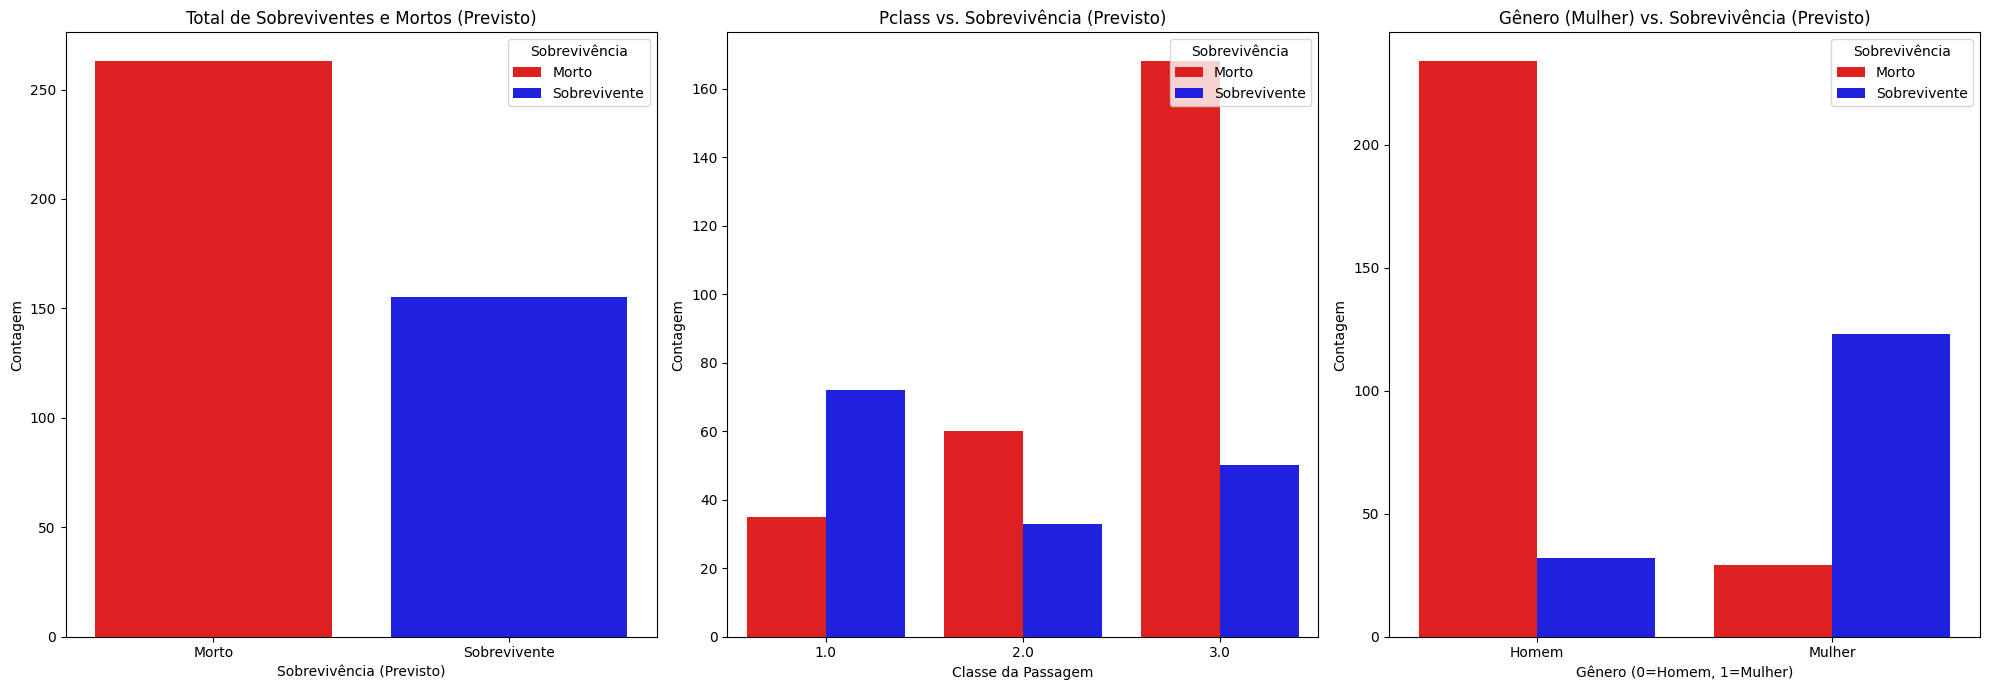

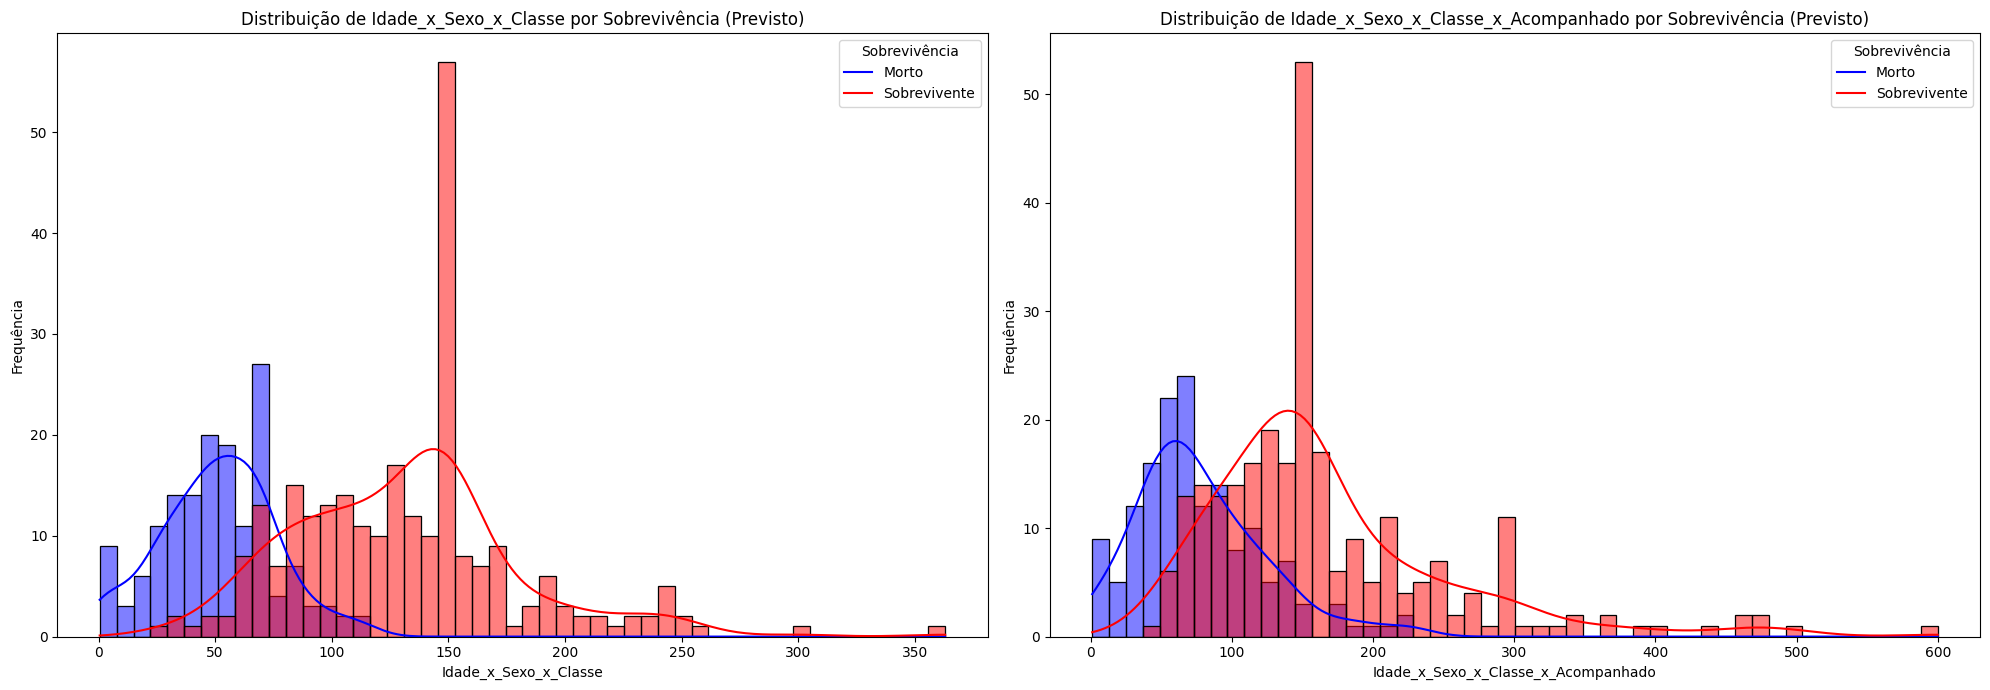

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

cor_sobrevivencia = {0: 'red', 1: 'blue'}

plt.figure(figsize=(20, 7))

# Gráfico 1.1: Quantidade total de Sobreviventes e Mortos (previstos)
plt.subplot(1, 3, 1)
sns.countplot(x='Survived', hue='Survived', data=titanic_teste_processado_df, palette=cor_sobrevivencia)
plt.title('Total de Sobreviventes e Mortos (Previsto)')
plt.xlabel('Sobrevivência (Previsto)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Morto', 'Sobrevivente'])
plt.legend(title='Sobrevivência', labels=['Morto', 'Sobrevivente'], loc='upper right')

# Gráfico 1.2: Sobreviventes e Mortos por Pclass
plt.subplot(1, 3, 2)
sns.countplot(x='originais__Pclass', hue='Survived', data=titanic_teste_processado_df, palette=cor_sobrevivencia)
plt.title('Pclass vs. Sobrevivência (Previsto)')
plt.xlabel('Classe da Passagem')
plt.ylabel('Contagem')
plt.legend(title='Sobrevivência', labels=['Morto', 'Sobrevivente'], loc='upper right')

# Gráfico 1.3: Sobreviventes e Mortos por Mulher
plt.subplot(1, 3, 3)
sns.countplot(x='originais__Mulher', hue='Survived', data=titanic_teste_processado_df, palette=cor_sobrevivencia)
plt.title('Gênero (Mulher) vs. Sobrevivência (Previsto)')
plt.xlabel('Gênero (0=Homem, 1=Mulher)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Homem', 'Mulher'])
plt.legend(title='Sobrevivência', labels=['Morto', 'Sobrevivente'], loc='upper right')

plt.tight_layout()
plt.show()

# 2. Gráficos de Distribuição (para variáveis contínuas engenheiradas)
plt.figure(figsize=(20, 7))

# Gráfico 2.1: Distribuição de Idade_x_Sexo_x_Classe por Sobrevivência (previsto)
plt.subplot(1, 2, 1)
sns.histplot(data=titanic_teste_processado_df, x='engenhadas__Idade_x_Sexo_x_Classe', hue='Survived', kde=True, bins=50, palette=cor_sobrevivencia)
plt.title('Distribuição de Idade_x_Sexo_x_Classe por Sobrevivência (Previsto)')
plt.xlabel('Idade_x_Sexo_x_Classe')
plt.ylabel('Frequência')
plt.legend(title='Sobrevivência', labels=['Morto', 'Sobrevivente'], loc='upper right')

# Gráfico 2.2: Distribuição de Idade_x_Sexo_x_Classe_x_Acompanhado por Sobrevivência (previsto)
plt.subplot(1, 2, 2)
sns.histplot(data=titanic_teste_processado_df, x='engenhadas__Idade_x_Sexo_x_Classe_x_Acompanhado', hue='Survived', kde=True, bins=50, palette=cor_sobrevivencia)
plt.title('Distribuição de Idade_x_Sexo_x_Classe_x_Acompanhado por Sobrevivência (Previsto)')
plt.xlabel('Idade_x_Sexo_x_Classe_x_Acompanhado')
plt.ylabel('Frequência')
plt.legend(title='Sobrevivência', labels=['Morto', 'Sobrevivente'], loc='upper right')

plt.tight_layout()
plt.show()